In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/liebe05/hetrec2011/MockData/tags.dat
/kaggle/input/datasets/liebe05/hetrec2011/MockData/user_taggedartists-timestamps.dat
/kaggle/input/datasets/liebe05/hetrec2011/MockData/readme.txt
/kaggle/input/datasets/liebe05/hetrec2011/MockData/artists.dat
/kaggle/input/datasets/liebe05/hetrec2011/MockData/user_taggedartists.dat
/kaggle/input/datasets/liebe05/hetrec2011/MockData/user_friends.dat
/kaggle/input/datasets/liebe05/hetrec2011/MockData/user_artists.dat


In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print("📂", dirname)
    for f in filenames:
        print("   └──", f)

📂 /kaggle/input
📂 /kaggle/input/datasets
📂 /kaggle/input/datasets/liebe05
📂 /kaggle/input/datasets/liebe05/hetrec2011
📂 /kaggle/input/datasets/liebe05/hetrec2011/MockData
   └── tags.dat
   └── user_taggedartists-timestamps.dat
   └── readme.txt
   └── artists.dat
   └── user_taggedartists.dat
   └── user_friends.dat
   └── user_artists.dat


## 1. ĐỌC DỮ LIỆU THÔ

In [3]:
import pandas as pd
import numpy as np
import pickle

file_path = "/kaggle/input/datasets/liebe05/hetrec2011/MockData/user_artists.dat"
df = pd.read_csv(file_path, sep='\t')

print("--- 5 DÒNG DỮ LIỆU GỐC ---")
print(df.head())

--- 5 DÒNG DỮ LIỆU GỐC ---
   userID  artistID  weight
0       2        51   13883
1       2        52   11690
2       2        53   11351
3       2        54   10300
4       2        55    8983


## 2. XỬ LÝ SMART RATING (QUANTILE)

### Lấy các mốc 20%, 40%, 60%, 80% để chia dữ liệu

In [4]:
print("\nĐang quy đổi lượt nghe (weight) sang sao (rating)...")

bins = df['weight'].quantile([0, 0.2, 0.4, 0.6, 0.8, 1.0]).unique()
labels = range(1, len(bins))


Đang quy đổi lượt nghe (weight) sang sao (rating)...


### Tạo cột rating mới

In [5]:
df['rating'] = pd.cut(df['weight'], bins=bins, labels=labels, include_lowest=True).astype(int)

## 3. LABEL ENCODING (CHUẨN HÓA ID CHO AI)

In [6]:
print("\nĐang chuẩn hóa ID liên tục cho Keras...")

df['user_index'], user_uniques = pd.factorize(df['userID'])
df['item_index'], item_uniques = pd.factorize(df['artistID'])


Đang chuẩn hóa ID liên tục cho Keras...


In [7]:
print(df.head())

   userID  artistID  weight  rating  user_index  item_index
0       2        51   13883       5           0           0
1       2        52   11690       5           0           1
2       2        53   11351       5           0           2
3       2        54   10300       5           0           3
4       2        55    8983       5           0           4


## 4. TRÍCH XUẤT VÀ LƯU FILE BÀN GIAO CHO THẠCH


### Tạo từ điển (dictionary) để map ngược từ Index của AI ra ID thật của Database

In [8]:
user_mapping = {index: id for index, id in enumerate(user_uniques)}
item_mapping = {index: id for index, id in enumerate(item_uniques)}

### Lưu ra file .pkl (Pickle) để dùng cho API

In [9]:
with open('user_to_index.pkl', 'wb') as f:
    pickle.dump(user_mapping, f)
with open('item_to_index.pkl', 'wb') as f:
    pickle.dump(item_mapping, f)

### Lấy 3 cột cốt lõi cho mạng NCF

In [10]:
ncf_input_df = df[['user_index', 'item_index', 'rating']]

NUM_USERS = df['user_index'].nunique()
NUM_ITEMS = df['item_index'].nunique()

print("\n--- DỮ LIỆU ĐÃ SẴN SÀNG CHO NCF ---")
print(f"Tổng số User: {NUM_USERS} | Tổng số Artist (Bài hát): {NUM_ITEMS}")
print(ncf_input_df.head())
print("\n(Đã lưu thành công 2 file mapping .pkl vào thư mục /kaggle/working/ )")



--- DỮ LIỆU ĐÃ SẴN SÀNG CHO NCF ---
Tổng số User: 1892 | Tổng số Artist (Bài hát): 17632
   user_index  item_index  rating
0           0           0       5
1           0           1       5
2           0           2       5
3           0           3       5
4           0           4       5

(Đã lưu thành công 2 file mapping .pkl vào thư mục /kaggle/working/ )


### Xem thử 2 file .pkl lưu gì

In [11]:
import pickle

# 1. Đọc ngược file Pickle lên lại bộ nhớ (dùng 'rb' - read binary)
with open('user_to_index.pkl', 'rb') as f:
    user_mapping_check = pickle.load(f)

with open('item_to_index.pkl', 'rb') as f:
    item_mapping_check = pickle.load(f)

print("--- BỘ TỪ ĐIỂN MAP NGƯỢC ---")

# Chuyển Dictionary thành List để chỉ in ra 5 người đầu tiên cho đỡ dài
print("\n1. Mẫu 5 User đầu tiên (Index AI -> ID gốc):")
print(list(user_mapping_check.items())[:5])

print("\n2. Mẫu 5 Artist đầu tiên (Index AI -> ID gốc):")
print(list(item_mapping_check.items())[:5])

--- BỘ TỪ ĐIỂN MAP NGƯỢC ---

1. Mẫu 5 User đầu tiên (Index AI -> ID gốc):
[(0, 2), (1, 3), (2, 4), (3, 5), (4, 6)]

2. Mẫu 5 Artist đầu tiên (Index AI -> ID gốc):
[(0, 51), (1, 52), (2, 53), (3, 54), (4, 55)]


In [12]:
# Lưu lại file dữ liệu đã xử lý để dùng cho API
df.to_csv('lastfm_clean.csv', index=False)
print("Đã xuất file lastfm_clean.csv thành công!")

Đã xuất file lastfm_clean.csv thành công!


## 5. Xây dựng Kiến trúc mạng nơ-ron NCF.

In [13]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Flatten, Concatenate, Dense, Dropout
from tensorflow.keras.models import Model

2026-04-05 16:17:30.463058: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775405850.662077      25 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775405850.724567      25 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775405851.161193      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775405851.161242      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775405851.161245      25 computation_placer.cc:177] computation placer alr

### BƯỚC 1: CHIA DỮ LIỆU HUẤN LUYỆN VÀ KIỂM TRA
Lấy ncf_input_df, chia 80% để AI học (Train), 20% để làm bài kiểm tra (Test)

In [14]:
print("1. Đang chia tập dữ liệu...")

train_data, test_data = train_test_split(ncf_input_df, test_size=0.2, random_state=42)

print(f"-> Số dòng để AI Học (Train): {len(train_data)}")
print(f"-> Số dòng để AI Kiểm tra (Test): {len(test_data)}")

1. Đang chia tập dữ liệu...
-> Số dòng để AI Học (Train): 74267
-> Số dòng để AI Kiểm tra (Test): 18567


### BƯỚC 2: XÂY DỰNG KIẾN TRÚC MẠNG NCF

In [15]:
print("\n2. Đang khởi tạo kiến trúc mạng NCF...")

def build_ncf_model(num_users, num_items, embedding_size=32, dropout_rate=0.2, learning_rate=0.001):
    # 1. Tầng Input: Khai báo cửa ngõ nhận dữ liệu
    user_input = Input(shape=(1,), name='user_input')
    item_input = Input(shape=(1,), name='item_input')

    # 2. Tầng Embedding: Biến ID thành Vector không gian (32 chiều)
    user_embedding = Embedding(input_dim=num_users, output_dim=embedding_size, name='user_emb')(user_input)
    item_embedding = Embedding(input_dim=num_items, output_dim=embedding_size, name='item_emb')(item_input)

    # 3. Tầng Flatten: Ép dẹp ma trận Embedding thành mảng 1 chiều
    user_vec = Flatten(name='flatten_user')(user_embedding)
    item_vec = Flatten(name='flatten_item')(item_embedding)

    # 4. Tầng Concatenate: Nối vector User và vector Bài hát thành một hàng dài
    concat = Concatenate(name='concat_layer')([user_vec, item_vec])

    # 5. Tầng Dense (MLP - Multi-Layer Perceptron): Mạng nơ-ron học quy luật phi tuyến tính
    # Hàm kích hoạt 'relu' giúp AI loại bỏ các tín hiệu âm (nhiễu)
    mlp_1 = Dense(64, activation='relu', name='mlp_1')(concat)
    drop_1 = Dropout(dropout_rate)(mlp_1) # Tắt ngẫu nhiên x% nơ-ron để chống "học vẹt" (Overfitting)

    mlp_2 = Dense(32, activation='relu', name='mlp_2')(drop_1)
    drop_2 = Dropout(dropout_rate)(mlp_2)

    mlp_3 = Dense(16, activation='relu', name='mlp_3')(drop_2)

    # 6. Tầng Output: Xuất ra 1 con số duy nhất (Dự đoán điểm Rating)
    # Dùng hàm 'linear' vì ta muốn dự đoán một con số thực (ví dụ 4.2 sao) chứ không phải phân loại
    output = Dense(1, activation='linear', name='prediction_ouput')(mlp_3)

    # Đóng gói tất cả các tầng lại thành một Mô hình (Model)
    model = Model(inputs=[user_input, item_input], outputs=output)

    # Biên dịch mô hình: 
    # - optimizer='adam': Thuật toán giúp AI tự sửa sai sau mỗi lần đoán.
    # - loss='mse': Dùng Sai số toàn phương trung bình (Mean Squared Error) để chấm điểm AI.
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae', tf.keras.metrics.RootMeanSquaredError(name='rmse')]
    )

    return model


2. Đang khởi tạo kiến trúc mạng NCF...


### Gọi hàm để tạo mô hình thực tế bằng các biến NUM_USERS và NUM_ITEMS đã có 

In [16]:
ncf_model = build_ncf_model(NUM_USERS, NUM_ITEMS)

I0000 00:00:1775405873.882596      25 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


### In ra bảng tổng kết kiến trúc mạng (Đây là cái sẽ chụp đưa vào báo cáo)

In [17]:
ncf_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_emb            │ (None, 1, 32)     │     60,544 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_emb            │ (None, 1, 32)     │    564,224 │ item_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_user        │ (None, 32)        │          0 │ user_emb[0][0]    │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_item        │ (None, 32)        │          0 │ item_emb[0][0]    │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_layer        │ (None, 64)        │          0 │ flatten_user[0][… │
│ (Concatenate)       │                   │            │ flatten_item[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_1 (Dense)       │ (None, 64)        │      4,160 │ concat_layer[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ mlp_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_2 (Dense)       │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ mlp_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_3 (Dense)       │ (None, 16)        │        528 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prediction_ouput    │ (None, 1)         │         17 │ mlp_3[0][0]       │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 631,553 (2.41 MB)

 Trainable params: 631,553 (2.41 MB)

 Non-trainable params: 0 (0.00 B)

## 6. BẮT ĐẦU TRAINING

In [18]:
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

### Tách các cột ra thành các mảng numpy để ép vào Keras

In [19]:
print("1. Đang tách dữ liệu để nạp vào 2 cổng Input...")

train_user = train_data['user_index'].values
train_item = train_data['item_index'].values
train_rating = train_data['rating'].values

test_user = test_data['user_index'].values
test_item = test_data['item_index'].values
test_rating = test_data['rating'].values


1. Đang tách dữ liệu để nạp vào 2 cổng Input...


### Cài đặt cơ chế chống Overfitting: 
Nếu AI thi thử (val_loss) mà 3 vòng liên tiếp (patience=3) không tiến bộ, hệ thống sẽ ép ngừng học ngay lập tức để tránh học vẹt!

In [20]:
print("\n2. Cài đặt cơ chế 'Kỷ luật thép' (Early Stopping)...")
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


2. Cài đặt cơ chế 'Kỷ luật thép' (Early Stopping)...


### Hàm fit() sẽ kích hoạt quá trình học tập


3. BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH (GPU ĐANG CHẠY HẾT TỐC LỰC!)...
Epoch 1/15


I0000 00:00:1775405876.919718      70 service.cc:152] XLA service 0x79e4cc00be80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775405876.919751      70 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775405877.260342      70 cuda_dnn.cc:529] Loaded cuDNN version 91002


 68/291 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.2962 - mae: 2.6735 - rmse: 3.0396 

I0000 00:00:1775405878.970443      70 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


291/291 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 4.9295 - mae: 1.7217 - rmse: 2.1487 - val_loss: 0.7392 - val_mae: 0.6583 - val_rmse: 0.8598
Epoch 2/15
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8660 - mae: 0.7155 - rmse: 0.9306 - val_loss: 0.7380 - val_mae: 0.6566 - val_rmse: 0.8591
Epoch 3/15
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7868 - mae: 0.6765 - rmse: 0.8870 - val_loss: 0.7550 - val_mae: 0.6590 - val_rmse: 0.8689
Epoch 4/15
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7335 - mae: 0.6461 - rmse: 0.8565 - val_loss: 0.7554 - val_mae: 0.6704 - val_rmse: 0.8691
Epoch 5/15
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6910 - mae: 0.6258 - rmse: 0.8312 - val_loss: 0.7400 - val_mae: 0.6553 - val_rmse: 0.8602

4. Đang vẽ biểu đồ Đánh giá (Đồ thị Loss Curve)...


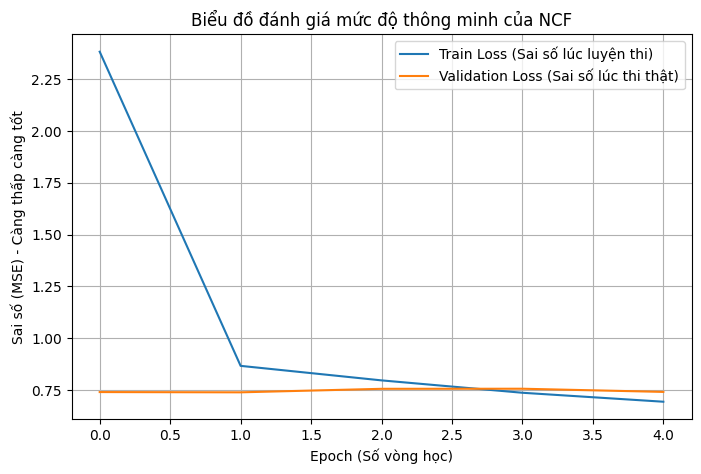

In [21]:
print("\n3. BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH (GPU ĐANG CHẠY HẾT TỐC LỰC!)...")

history = ncf_model.fit(
    x=[train_user, train_item], # Nạp Index User và Index Nhạc vào 2 cổng Input
    y=train_rating,             # Đáp án thực tế để AI đối chiếu và tự sửa sai
    batch_size=256,             # Mỗi mẻ học nhồi 256 cặp dữ liệu vào
    epochs=15,                  # Cho học đi học lại tập dữ liệu tối đa 15 lần
    validation_data=([test_user, test_item], test_rating), # Tập thi thử (20% Test) để chấm điểm sau mỗi mẻ
    callbacks=[early_stop],
    verbose=1
)


print("\n4. Đang vẽ biểu đồ Đánh giá (Đồ thị Loss Curve)...")
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss (Sai số lúc luyện thi)')
plt.plot(history.history['val_loss'], label='Validation Loss (Sai số lúc thi thật)')
plt.title('Biểu đồ đánh giá mức độ thông minh của NCF')
plt.ylabel('Sai số (MSE) - Càng thấp càng tốt')
plt.xlabel('Epoch (Số vòng học)')
plt.legend()
plt.grid(True)
plt.show()



## 7. Tinh chỉnh (Tuning)

--- Đang chạy Thử nghiệm 1 (Bản gốc) ---
Epoch 1/15
291/291 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 5.3123 - mae: 1.8039 - rmse: 2.2376 - val_loss: 0.7529 - val_mae: 0.6581 - val_rmse: 0.8677
Epoch 2/15
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8405 - mae: 0.7037 - rmse: 0.9168 - val_loss: 0.7571 - val_mae: 0.6628 - val_rmse: 0.8701
Epoch 3/15
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7487 - mae: 0.6585 - rmse: 0.8652 - val_loss: 0.8237 - val_mae: 0.6990 - val_rmse: 0.9076
Epoch 4/15
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7022 - mae: 0.6327 - rmse: 0.8380 - val_loss: 0.8617 - val_mae: 0.7119 - val_rmse: 0.9283

--- Đang chạy Thử nghiệm 2 (Tuning) ---
Epoch 1/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 6.3487 - mae: 2.0583 - rmse: 2.4727 - val_loss: 0.7638 - val_mae: 0.6696 - val_rmse: 0.8740
Epoch 2/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0959 - mae: 0.8040 - rmse: 1.0468 - val_loss: 0.7394 - val_mae: 0.6586 - val_rmse: 0.8599
Epoc

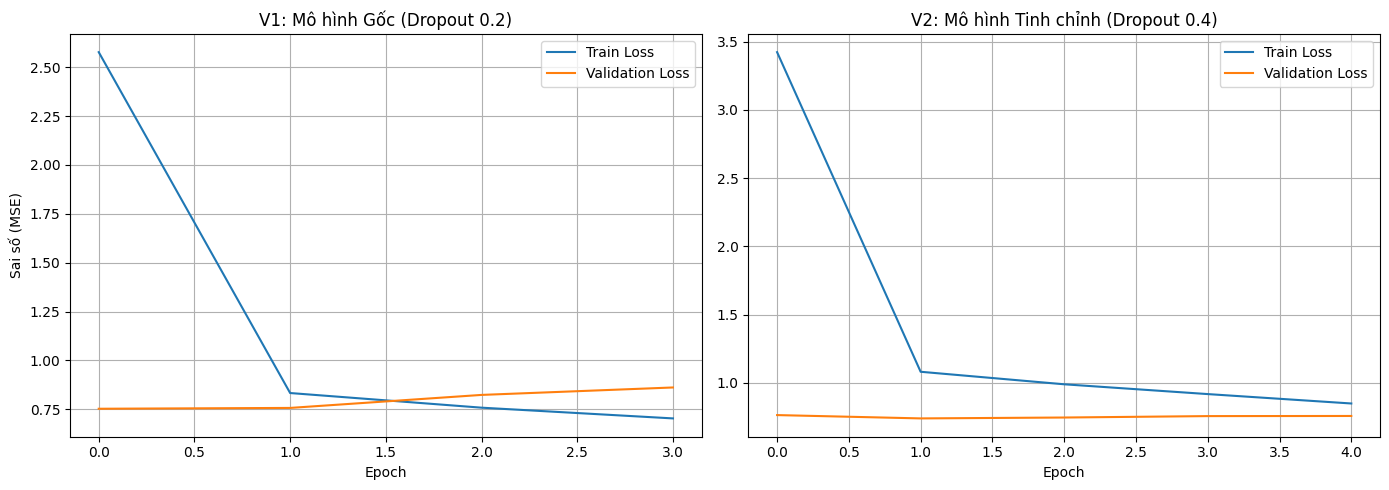

In [22]:
# THỬ NGHIỆM 1: Chạy mô hình gốc (Dropout 0.2, Tốc độ học 0.001)
print("--- Đang chạy Thử nghiệm 1 (Bản gốc) ---")
model_v1 = build_ncf_model(NUM_USERS, NUM_ITEMS, dropout_rate=0.2, learning_rate=0.001)
history_v1 = model_v1.fit(
    x=[train_user, train_item], # Nạp Index User và Index Nhạc vào 2 cổng Input
    y=train_rating,             # Đáp án thực tế để AI đối chiếu và tự sửa sai
    batch_size=256,             # Mỗi mẻ học nhồi 256 cặp dữ liệu vào
    epochs=15,                  # Cho học đi học lại tập dữ liệu tối đa 15 lần
    validation_data=([test_user, test_item], test_rating), # Tập thi thử (20% Test) để chấm điểm sau mỗi mẻ
    callbacks=[early_stop],
    verbose=1
)

# THỬ NGHIỆM 2: Tinh chỉnh ép AI suy luận (Dropout 0.4, Tốc độ học chậm lại 0.0005)
print("\n--- Đang chạy Thử nghiệm 2 (Tuning) ---")
model_v2 = build_ncf_model(NUM_USERS, NUM_ITEMS, dropout_rate=0.4, learning_rate=0.0005)
history_v2 = model_v2.fit(
    x=[train_user, train_item], 
    y=train_rating,             
    batch_size=256,             
    epochs=10,                  
    validation_data=([test_user, test_item], test_rating), 
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)

# VẼ BIỂU ĐỒ SO SÁNH
print("\n4. Đang vẽ biểu đồ Đánh giá (Đồ thị Loss Curve)...")
plt.figure(figsize=(14, 5))

# Biểu đồ 1: V1
plt.subplot(1, 2, 1) # Vẽ ở nửa trái màn hình
plt.plot(history_v1.history['loss'], label='Train Loss')
plt.plot(history_v1.history['val_loss'], label='Validation Loss')
plt.title('V1: Mô hình Gốc (Dropout 0.2)')
plt.ylabel('Sai số (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)

# Biểu đồ 2: V2
plt.subplot(1, 2, 2) # Vẽ ở nửa phải màn hình
plt.plot(history_v2.history['loss'], label='Train Loss')
plt.plot(history_v2.history['val_loss'], label='Validation Loss')
plt.title('V2: Mô hình Tinh chỉnh (Dropout 0.4)')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## 8. VIẾT HÀM DỰ ĐOÁN

In [23]:
import numpy as np

def get_top10_recommendations(user_index, model, total_items):
    print(f"Đang phân tích dữ liệu cho User Index: {user_index}...")

    # 1. Tạo danh sách chứa toàn bộ Item Index (từ 0 đến NUM_ITEMS - 1)
    all_items = np.arange(total_items)

    # 2. Nhân bản User Index lên để ghép cặp với từng Item
    # Ví dụ: [(User 0, Item 0), (User 0, Item 1), ..., (User 0, Item 17631)]
    user_array = np.full(total_items, user_index)

    # 3. Đưa vào mô hình để dự đoán điểm số (Rating) cho TẤT CẢ bài hát
    # Set verbose=0 để ẩn thanh tiến trình chạy cho đỡ rối mắt
    predictions = model.predict([user_array, all_items], batch_size=512, verbose=0)

    # 4. Ép dẹp mảng dự đoán và sắp xếp điểm từ cao xuống thấp
    predictions = predictions.flatten()

    # argsort() sắp xếp từ bé đến lớn, lấy [-10:] (10 cái cuối cùng) và đảo ngược [::-1]
    top10_item_indices = predictions.argsort()[-10:][::-1]
    top10_scores = predictions[top10_item_indices]

    # Ép mọi điểm số phải nằm gọn trong khoảng từ 1.0 đến 5.0
    # top10_scores = np.clip(top10_scores, 1.0, 5.0)

    return top10_item_indices, top10_scores
    

### Test thử với User Index = 0

In [24]:
# LẦN 1, ncf_model
test_user = 0

top_items, scores = get_top10_recommendations(test_user, ncf_model, NUM_ITEMS)

print("\n--- KẾT QUẢ GỢI Ý TỪ DEEP LEARNING (NCF) ---")
for i in range(10):
    print(f"Top {i+1}: Bài hát (Item Index) {top_items[i]} | Điểm AI dự đoán: {scores[i]:.2f} sao")

Đang phân tích dữ liệu cho User Index: 0...

--- KẾT QUẢ GỢI Ý TỪ DEEP LEARNING (NCF) ---
Top 1: Bài hát (Item Index) 238 | Điểm AI dự đoán: 5.63 sao
Top 2: Bài hát (Item Index) 21 | Điểm AI dự đoán: 5.38 sao
Top 3: Bài hát (Item Index) 629 | Điểm AI dự đoán: 5.36 sao
Top 4: Bài hát (Item Index) 14680 | Điểm AI dự đoán: 5.35 sao
Top 5: Bài hát (Item Index) 7131 | Điểm AI dự đoán: 5.29 sao
Top 6: Bài hát (Item Index) 38 | Điểm AI dự đoán: 5.27 sao
Top 7: Bài hát (Item Index) 1615 | Điểm AI dự đoán: 5.25 sao
Top 8: Bài hát (Item Index) 2018 | Điểm AI dự đoán: 5.25 sao
Top 9: Bài hát (Item Index) 12538 | Điểm AI dự đoán: 5.25 sao
Top 10: Bài hát (Item Index) 241 | Điểm AI dự đoán: 5.24 sao


In [25]:
# LẦN 2, model_v1
test_user = 0

top_items, scores = get_top10_recommendations(test_user, model_v1, NUM_ITEMS)

print("\n--- KẾT QUẢ GỢI Ý TỪ DEEP LEARNING (NCF) ---")
for i in range(10):
    print(f"Top {i+1}: Bài hát (Item Index) {top_items[i]} | Điểm AI dự đoán: {scores[i]:.2f} sao")

Đang phân tích dữ liệu cho User Index: 0...

--- KẾT QUẢ GỢI Ý TỪ DEEP LEARNING (NCF) ---
Top 1: Bài hát (Item Index) 238 | Điểm AI dự đoán: 5.48 sao
Top 2: Bài hát (Item Index) 21 | Điểm AI dự đoán: 5.23 sao
Top 3: Bài hát (Item Index) 241 | Điểm AI dự đoán: 5.23 sao
Top 4: Bài hát (Item Index) 629 | Điểm AI dự đoán: 5.18 sao
Top 5: Bài hát (Item Index) 249 | Điểm AI dự đoán: 5.17 sao
Top 6: Bài hát (Item Index) 38 | Điểm AI dự đoán: 5.17 sao
Top 7: Bài hát (Item Index) 237 | Điểm AI dự đoán: 5.15 sao
Top 8: Bài hát (Item Index) 176 | Điểm AI dự đoán: 5.07 sao
Top 9: Bài hát (Item Index) 293 | Điểm AI dự đoán: 5.07 sao
Top 10: Bài hát (Item Index) 448 | Điểm AI dự đoán: 5.05 sao


In [26]:
# LẦN 2, model_v2
test_user = 0

top_items, scores = get_top10_recommendations(test_user, model_v2, NUM_ITEMS)

print("\n--- KẾT QUẢ GỢI Ý TỪ DEEP LEARNING (NCF) ---")
for i in range(10):
    print(f"Top {i+1}: Bài hát (Item Index) {top_items[i]} | Điểm AI dự đoán: {scores[i]:.2f} sao")

Đang phân tích dữ liệu cho User Index: 0...

--- KẾT QUẢ GỢI Ý TỪ DEEP LEARNING (NCF) ---
Top 1: Bài hát (Item Index) 238 | Điểm AI dự đoán: 5.52 sao
Top 2: Bài hát (Item Index) 241 | Điểm AI dự đoán: 5.37 sao
Top 3: Bài hát (Item Index) 21 | Điểm AI dự đoán: 5.37 sao
Top 4: Bài hát (Item Index) 629 | Điểm AI dự đoán: 5.17 sao
Top 5: Bài hát (Item Index) 38 | Điểm AI dự đoán: 5.16 sao
Top 6: Bài hát (Item Index) 237 | Điểm AI dự đoán: 5.14 sao
Top 7: Bài hát (Item Index) 325 | Điểm AI dự đoán: 5.09 sao
Top 8: Bài hát (Item Index) 763 | Điểm AI dự đoán: 5.09 sao
Top 9: Bài hát (Item Index) 249 | Điểm AI dự đoán: 5.06 sao
Top 10: Bài hát (Item Index) 176 | Điểm AI dự đoán: 5.06 sao


### Tăng Dropout từ 0.2 lên 0.4 để mô hình bớt "Học vẹt"

## 9. Lưu Mô hình
Lưu mô hình (Keras 3 khuyến nghị dùng đuôi .keras thay vì .h5)

In [27]:
print("\n2. Đang xuất khẩu mô hình ra file...")

model_v2.save('ncf_model_v2.keras')
print("[THÀNH CÔNG] Đã lưu file 'ncf_model.keras' vào thư mục /kaggle/working/")


2. Đang xuất khẩu mô hình ra file...
[THÀNH CÔNG] Đã lưu file 'ncf_model.keras' vào thư mục /kaggle/working/


## Kiểm tra Định tính

In [28]:
import pandas as pd

# 1. Đọc danh sách Tên ca sĩ thật từ file
artists_df = pd.read_csv('/kaggle/input/datasets/liebe05/hetrec2011/MockData/artists.dat', sep='\t')

# --- ĐIỂM SỬA CHỮA Ở ĐÂY ---
# Đọc lại file dữ liệu gốc để chắc chắn có cột 'weight'
full_data = pd.read_csv('lastfm_clean.csv') 

# 2. Truy xuất Lịch sử nghe nhạc gốc của User 0 trên FULL DATA
user0_history_idx = full_data[(full_data['user_index'] == test_user) & (full_data['rating'] == 5)] \
                    .sort_values(by='weight', ascending=False)['item_index'].values

print("=== BƯỚC 1: SOI LỊCH SỬ NGHE NHẠC THẬT CỦA USER 0 ===")
print("User 0 là fan cuồng của những ca sĩ nào?")
# In thử 5 ca sĩ mà User 0 đã cày view nhiều nhất
for idx in user0_history_idx[:5]: 
    real_id = item_mapping_check[idx] # Dịch Index AI sang ID thật
    artist_name = artists_df[artists_df['id'] == real_id]['name'].values[0] # Tra bảng lấy tên
    print(f"🎵 Đã nghe: {artist_name}")

=== BƯỚC 1: SOI LỊCH SỬ NGHE NHẠC THẬT CỦA USER 0 ===
User 0 là fan cuồng của những ca sĩ nào?
🎵 Đã nghe: Duran Duran
🎵 Đã nghe: Morcheeba
🎵 Đã nghe: Air
🎵 Đã nghe: Hooverphonic
🎵 Đã nghe: Kylie Minogue


In [29]:
print("\n=== BƯỚC 2: BÀI TEST SỰ THÔNG MINH CỦA AI (NCF) ===")
print("Với gu âm nhạc trên, AI khuyên User 0 nên nghe tiếp ai?")
# Lấy danh sách top_items và scores từ ô code dự đoán lúc nãy
for i in range(5):
    idx = top_items[i]
    real_id = item_mapping_check[idx]
    artist_name = artists_df[artists_df['id'] == real_id]['name'].values[0]
    print(f"✨ AI Gợi ý Top {i+1}: {artist_name} | Tự tin: {scores[i]:.2f} sao")


=== BƯỚC 2: BÀI TEST SỰ THÔNG MINH CỦA AI (NCF) ===
Với gu âm nhạc trên, AI khuyên User 0 nên nghe tiếp ai?
✨ AI Gợi ý Top 1: Britney Spears | Tự tin: 5.52 sao
✨ AI Gợi ý Top 2: Christina Aguilera | Tự tin: 5.37 sao
✨ AI Gợi ý Top 3: Depeche Mode | Tự tin: 5.37 sao
✨ AI Gợi ý Top 4: Glee Cast | Tự tin: 5.17 sao
✨ AI Gợi ý Top 5: Lady Gaga | Tự tin: 5.16 sao
